# Retail Sales Analysis — Business Analysis

In this notebook we answer key business questions using the Superstore dataset.

The goal is to identify profitability drivers, loss-generating products, and potential opportunities for improving business performance.

## Setup
Import libraries and load the dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/superstore.csv", encoding="latin1")


df["Order Date"] = pd.to_datetime(df["Order Date"])

## Business Question 1

Which regions generate the most sales?

In [2]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

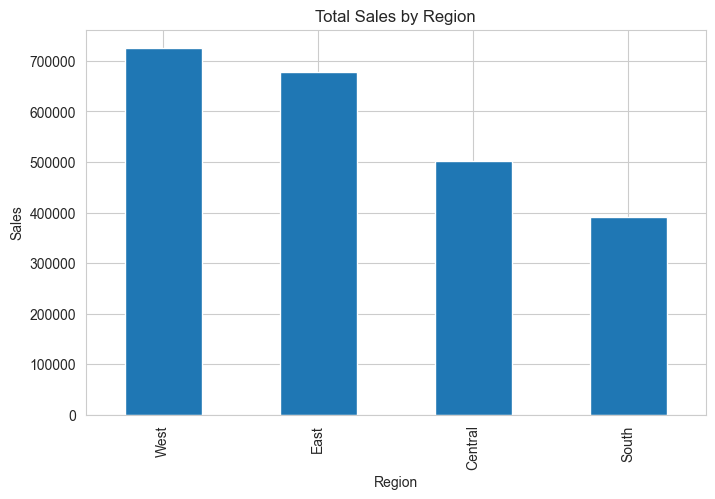

In [3]:
plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.ylabel("Sales")

plt.show()

### Insight

The West region generates the highest total sales, followed closely by the East region.

Central and South contribute significantly less to overall revenue, suggesting that market demand is stronger in the western and eastern parts of the country.

## Business Question 2

Which regions generate the most profit?

In [4]:
region_profit = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

region_profit

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

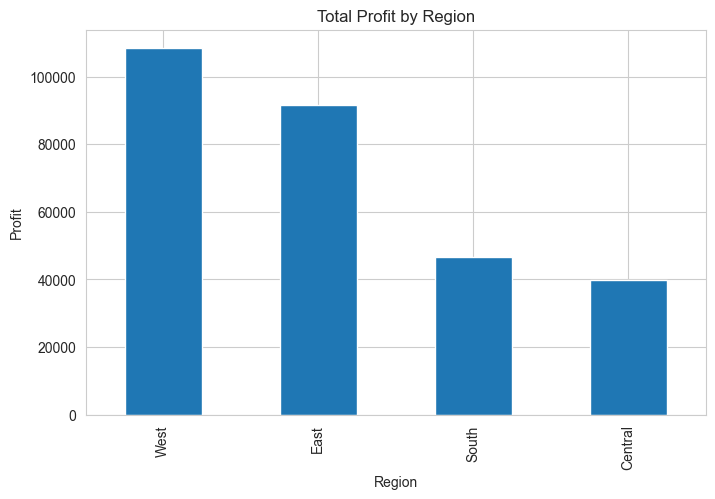

In [5]:
plt.figure(figsize=(8,5))

region_profit.plot(kind="bar")

plt.title("Total Profit by Region")
plt.ylabel("Profit")

plt.show()

### Insight

The West region generates the highest profit, followed by the East region.

Although the Central region produces higher sales than the South, it generates less profit, suggesting lower margins or higher discounts in that region.

## Business Question 3

Which customers generate the most sales?

In [6]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

top_customers.head(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

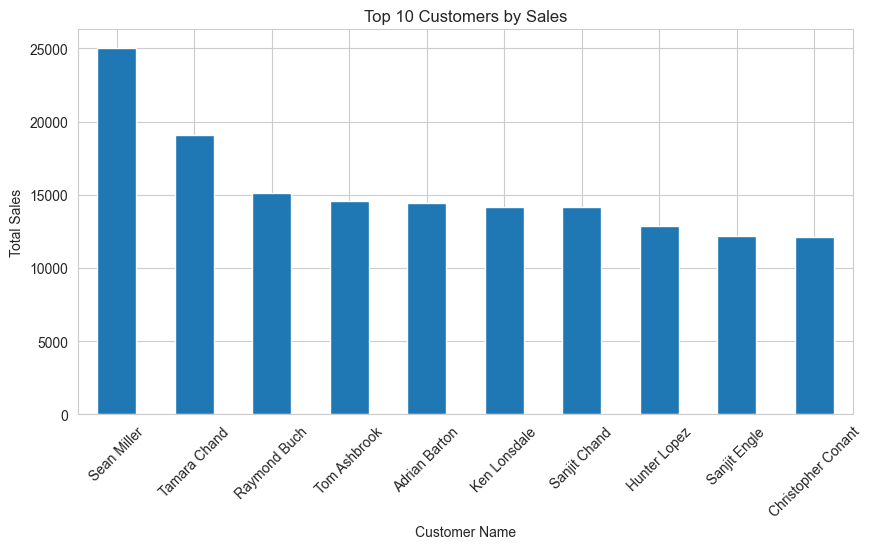

In [7]:
plt.figure(figsize=(10,5))

top_customers.head(10).plot(kind="bar")

plt.title("Top 10 Customers by Sales")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.show()

### Insight

Sean Miller and Tamara Chand are the customers generating the highest total sales.

Although sales are distributed across many customers, identifying and retaining high-value customers could help sustain revenue growth.

### Additional Check

How much of the total revenue is generated by the top 10 customers?

In [8]:
total_sales = df["Sales"].sum()

top10_sales = top_customers.head(10).sum()

top10_share = top10_sales / total_sales

top10_share

np.float64(0.06695590779985745)

### Insight

The top 10 customers account for only about 6.7% of total sales.

This indicates that revenue is relatively well distributed across many customers rather than being concentrated in a small group of high-value clients.

## Business Question 4

Which states generate the most sales?

In [9]:
state_sales = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

state_sales.head(10)

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

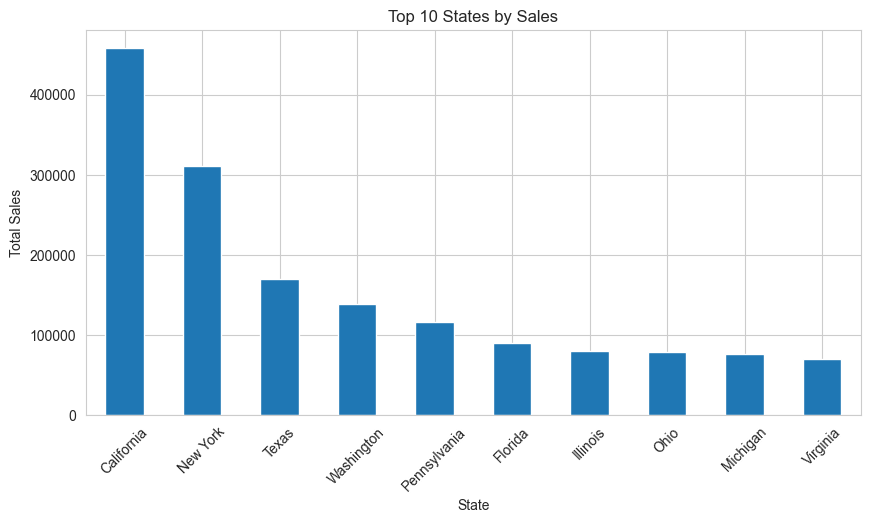

In [10]:
plt.figure(figsize=(10,5))

state_sales.head(10).plot(kind="bar")

plt.title("Top 10 States by Sales")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.show()

### Insight

California generates by far the highest total sales, followed by New York.

There is a significant drop after these two states, suggesting that a large portion of revenue is concentrated in a few major markets.

## Business Question 5

Which states generate the most profit?

In [11]:
state_profit = (
    df.groupby("State")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

state_profit.head(10)

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64

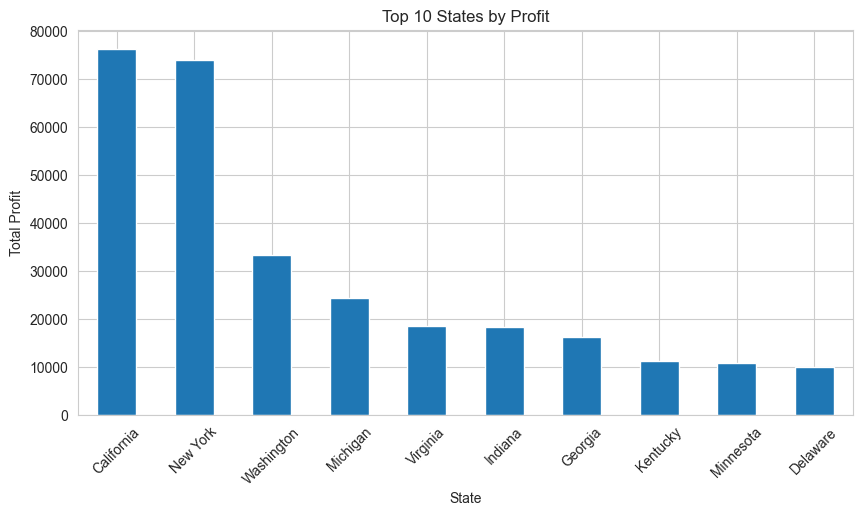

In [12]:
plt.figure(figsize=(10,5))

state_profit.head(10).plot(kind="bar")

plt.title("Top 10 States by Profit")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)
plt.show()

### Insight

California and New York generate the highest total profit, which is consistent with their high sales volumes.

Interestingly, Washington appears among the most profitable states despite not being among the top states in sales, suggesting stronger profit margins in that market.

## Business Question 6

Which states generate negative profit?

In [13]:
loss_states = (
    df.groupby("State")["Profit"]
    .sum()
    .sort_values()
)

loss_states.head(10)

State
Texas            -25729.3563
Ohio             -16971.3766
Pennsylvania     -15559.9603
Illinois         -12607.8870
North Carolina    -7490.9122
Colorado          -6527.8579
Tennessee         -5341.6936
Arizona           -3427.9246
Florida           -3399.3017
Oregon            -1190.4705
Name: Profit, dtype: float64

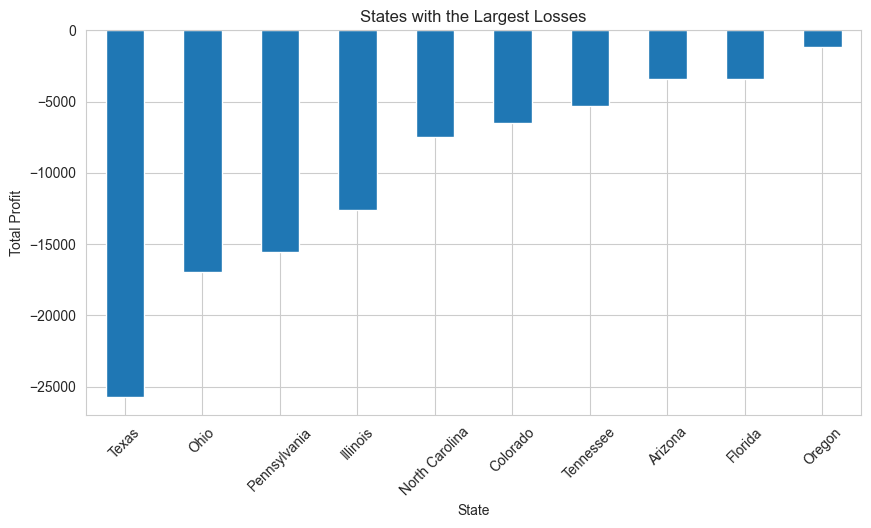

In [14]:
plt.figure(figsize=(10,5))

loss_states.head(10).plot(kind="bar")

plt.title("States with the Largest Losses")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)
plt.show()

### Insight

Some states generate negative total profit despite having positive sales.

This suggests that high discounts, product mix, or operational costs may be eroding margins in those markets. Texas, for example, shows the largest overall loss.

## Business Question 7

Which states have the lowest profit margins?

In [15]:
state_performance = df.groupby("State").agg({
    "Sales": "sum",
    "Profit": "sum"
})

state_performance["Profit Margin"] = state_performance["Profit"] / state_performance["Sales"]

state_performance.sort_values("Profit Margin").head(10)

,Sales,Profit,Profit Margin
State,,,
Ohio,78258.1360,-16971.3766,-0.216864
Colorado,32108.1180,-6527.8579,-0.203309
Tennessee,30661.8730,-5341.6936,-0.174213
Illinois,80166.1010,-12607.8870,-0.157272
Texas,170188.0458,-25729.3563,-0.151182
North Carolina,55603.1640,-7490.9122,-0.134721
Pennsylvania,116511.9140,-15559.9603,-0.133548
Arizona,35282.0010,-3427.9246,-0.097158
Oregon,17431.1500,-1190.4705,-0.068296


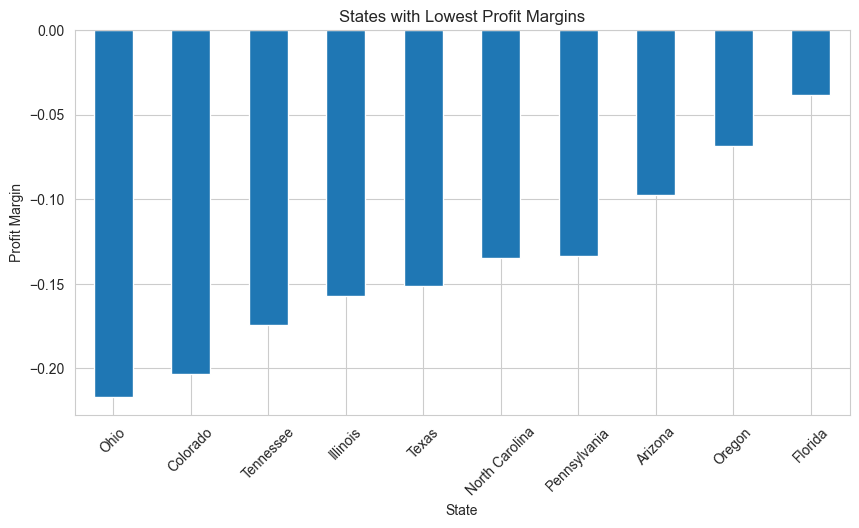

In [16]:
plt.figure(figsize=(10,5))

state_performance.sort_values("Profit Margin").head(10)["Profit Margin"].plot(kind="bar")

plt.title("States with Lowest Profit Margins")
plt.ylabel("Profit Margin")

plt.xticks(rotation=45)
plt.show()

### Insight

Several states show negative profit margins, meaning that the company loses money on average for each dollar sold in those markets.

For example, Ohio and Colorado exhibit particularly poor margins, suggesting that discounts, product mix, or operational costs may be significantly reducing profitability in those states.

## Business Question 8

How does profit vary by category across regions?

In [17]:
profit_region_category = (
    df.groupby(["Region", "Category"])["Profit"]
    .sum()
    .unstack()
)

profit_region_category

Category,Furniture,Office Supplies,Technology
Region,,,
Central,-2871.0494,8879.9799,33697.4320
East,3046.1658,41014.5791,47462.0351
South,6771.2061,19986.3928,19991.8314
West,11504.9503,52609.8490,44303.6496


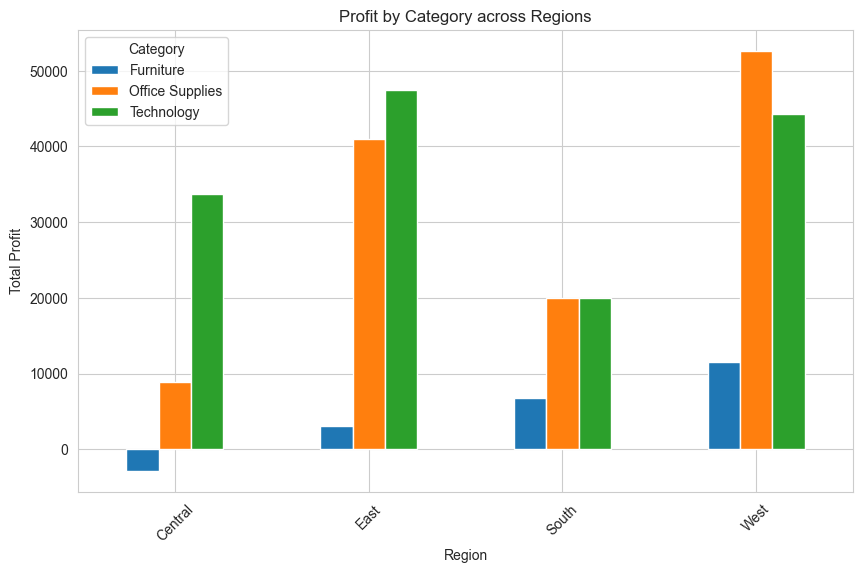

In [18]:
profit_region_category.plot(kind="bar", figsize=(10,6))

plt.title("Profit by Category across Regions")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)
plt.show()

### Insight

Technology is the most profitable category across all regions, consistently generating strong margins.

Office Supplies also performs well in most regions. In contrast, Furniture shows weaker performance and even generates losses in the Central region, suggesting potential pricing or cost structure issues in that category.

## Key Business Insights

- Sales are concentrated in the West and East regions.
- California and New York dominate both sales and profit generation.
- Several states exhibit negative profit margins, indicating potential issues with pricing, discounts, or product mix.
- Revenue is relatively distributed across many customers, with no strong customer concentration.
- Technology is the most profitable category across all regions, while Furniture shows weaker performance.